# 01 - Data exploration: what do our GitHub profiles look like?

Developer profiles are pulled from the **GitHub public API** and experiment outcomes are simulated on top by through simulate_cohort.py. 
The covariate structure (repo counts, account age, commit activity) are from real data.

**What this notebook establishes:**

1. What the profile distributions look like 
2. How profiles map to developer archetypes
3. Which covariates might be useful for variance reduction later

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.width", 120)
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})

PROFILES_PATH = "../data/profiles.csv"
sys.path.append(str(Path.cwd().parent))

profiles = pd.read_csv(PROFILES_PATH)
profiles["account_age_years"] = profiles["account_age_days"] / 365.25
profiles.head()

,username,account_age_days,repo_count,top_language,commit_streak,account_age_years
0,uprockcom,1556,20,Go,0,4.260096
1,unicity-astrid,147,36,Rust,0,0.402464
2,rustdesk,2120,10,Rust,94,5.804244
3,xiaojieonly,2656,40,Dart,100,7.271732
4,ed-donner,1667,39,Jupyter Notebook,100,4.563997


## Profile spread

The same summary data/github_fetch.py prints when it runs for N = 5,000:

```
Profile spread:
  Median repos        : 18
  Median commit_streak: 0
  Account age (yrs)   : 0.1 - 18.4
```

A median commit streak of zero creates pause- more than half the accounts sampled had no active streak at fetch time. GitHub visible activity is extremely
heavy tailed with a minority of very active developers and a long tail of quiet accounts.

In [2]:
print(f"  Median repos        : {profiles['repo_count'].median():.0f}")
print(f"  Median commit_streak: {profiles['commit_streak'].median():.0f}")
print(f"  Account age (yrs)   : {profiles['account_age_years'].min():.1f} - {profiles['account_age_years'].max():.1f}")

profiles[["repo_count", "commit_streak", "account_age_years"]].describe().round(2)


  Median repos        : 18
  Median commit_streak: 0
  Account age (yrs)   : 0.1 - 18.4


,repo_count,commit_streak,account_age_years
count,5000.00,5000.00,5000.00
mean,20.80,9.48,8.52
std,12.44,24.76,4.64
min,5.00,0.00,0.13
25%,11.00,0.00,4.54
50%,18.00,0.00,7.63
75%,29.00,2.00,12.68
max,50.00,100.00,18.39


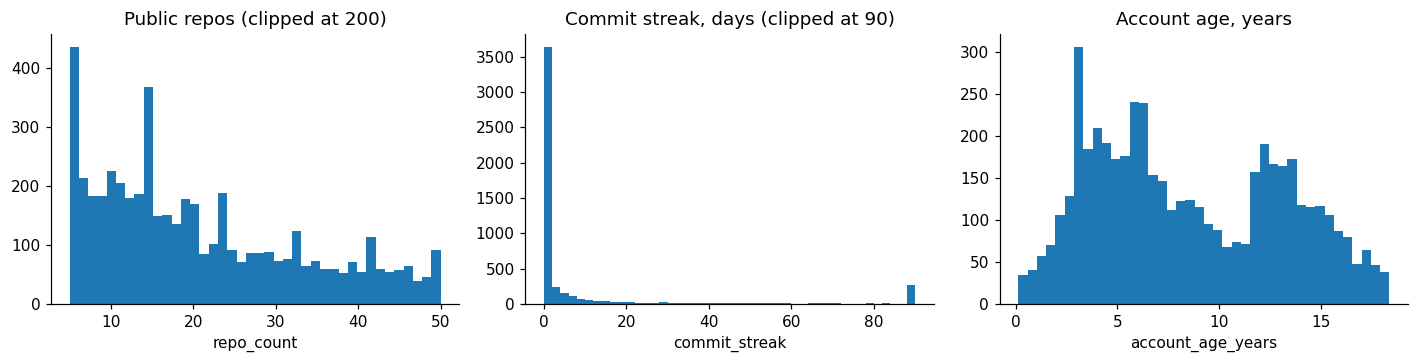

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.4))

axes[0].hist(profiles["repo_count"].clip(upper=200), bins=40)
axes[0].set_title("Public repos (clipped at 200)")
axes[0].set_xlabel("repo_count")

axes[1].hist(profiles["commit_streak"].clip(upper=90), bins=45)
axes[1].set_title("Commit streak, days (clipped at 90)")
axes[1].set_xlabel("commit_streak")

axes[2].hist(profiles["account_age_years"], bins=40)
axes[2].set_title("Account age, years")
axes[2].set_xlabel("account_age_years")

plt.tight_layout()
plt.show()


Everything is right skewed. Means can mislead, medians and quantiles don't.

## Languages

`top_language` is the most frequent language across each developer's recent public repos. 
Even if it is not an experiment metric, it is a useful sanity check that the sample looks like real developer population.

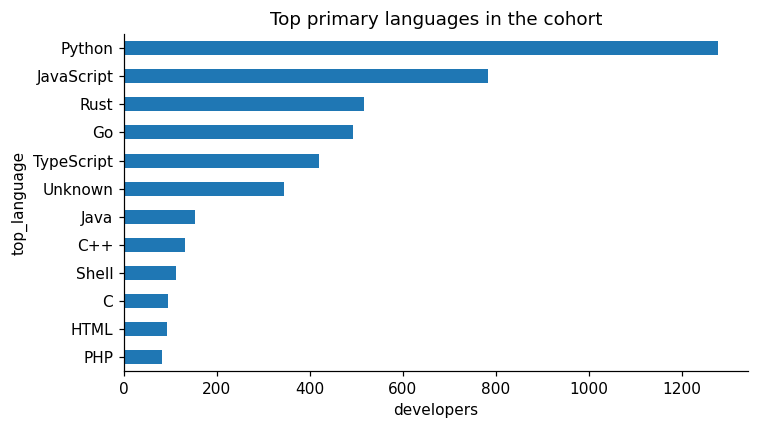

In [4]:
if "top_language" in profiles.columns:
    lang = profiles["top_language"].fillna("(none detected)").value_counts().head(12)
    ax = lang.sort_values().plot.barh(figsize=(7, 4))
    ax.set_title("Top primary languages in the cohort")
    ax.set_xlabel("developers")
    plt.tight_layout()
    plt.show()


## Archetypes

data/simulate_cohort.py groups developers into archetypes before simulating outcomes, so retention baselines differ realistically by segment (an experienced backend dev does
not churn like a brand-new account). 

| Archetype | Rule |
|---|---|
| `newcomer` | account younger than 180 days |
| `experienced` | 8+ years old & 20+ public repos |
| `active_hobbyist` | commit streak of 30+ days |
| `early_career` | everyone else |


Archetype breakdown:
  early_career     3,543
  experienced      1,054
  active_hobbyist  340
  newcomer         63


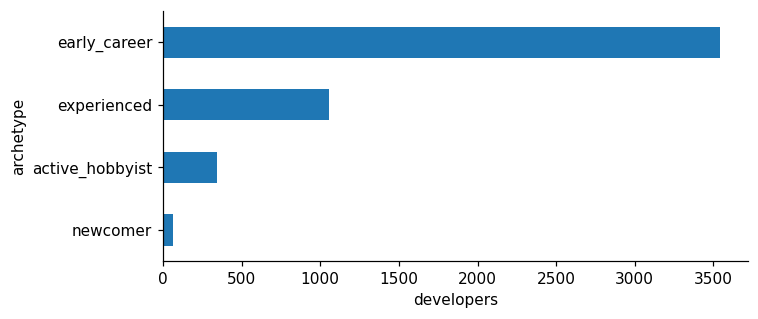

In [5]:
# data/simulate_cohort.py contains the archetype rules
from data.simulate_cohort import assign_archetype

if "archetype" not in profiles.columns:
    # assign_archetype works one row at a time, so apply it row-wise
    profiles["archetype"] = profiles.apply(assign_archetype, axis=1)

counts = profiles["archetype"].value_counts()
print("Archetype breakdown:")
for name, n in counts.items():
    print(f"  {name:<16} {n:,}")

ax = counts.sort_values().plot.barh(figsize=(7, 3))
ax.set_xlabel("developers")
plt.tight_layout()
plt.show()

In our N=5,000 cohort this came out as:

```
    early_career     3,543
    experienced      1,054
    active_hobbyist  340
    newcomer         63
```

Two design consequences are note worthy:

1. **The overall result will be dominated by early_career** (~71% of the cohort). If the tip only helps experienced developers, the pooled lift could be diluted.
2. **newcomer (n=63) can never support a subgroup claim.** At this small size, the CI on a retention difference spans roughly ±25pp.

## Do any covariates predict retention like behavior?

CUPED (in notebook 03) only pays off if a pre-experiment covariate correlates with the outcome. We can't check against retention yet since no outcomes exist at this design time, but we
can check that the candidate covariates carry signal and aren't degenerate or collinear.

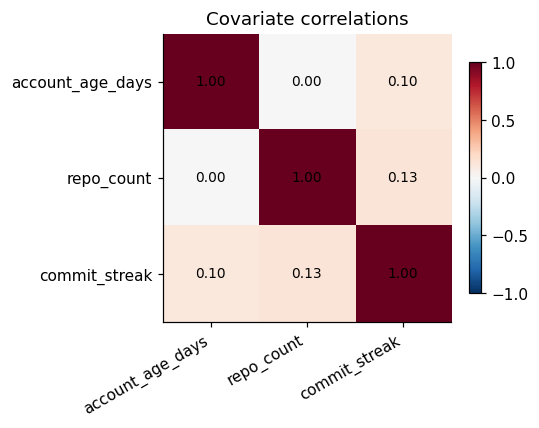

In [6]:
covs = ["account_age_days", "repo_count", "commit_streak"]
corr = profiles[covs].corr()

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r")
ax.set_xticks(range(len(covs)), covs, rotation=30, ha="right")
ax.set_yticks(range(len(covs)), covs)
for i in range(len(covs)):
    for j in range(len(covs)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=9)
fig.colorbar(im, shrink=0.8)
ax.set_title("Covariate correlations")
plt.tight_layout()
plt.show()

These covariates alone do not appear to strongly predict retention behavior based on this correlation matrix. 
They are mostly independent of each other, but this plot does not show their relationship with retention.

## Takeaways

- Distributions are heavy-tailed; any covariate used for adjustment should be transformed
  (log), which is why pre_experiment_score in the dbt mart uses ln(1+repos).
- The cohort is ~71% early-career; pooled effects will mostly reflect that segment.
- Tiny segments (newcomer) should be for monitoring, not decisions.